# Size-Based Subset: SAM-Med2D 256 vs PGA-UNet 256 vs PGA-UNet 512

| Section | Content |
|---|---|
| **0** | Select `small_lesion_stems`: the 50 test images with the smallest total lesion area |
| **1** | SAM-Med2D (256) - small-lesion subset + 10 qualitative examples |
| **2** | PGA-UNet (256) - small-lesion subset + 10 qualitative examples |
| **3** | PGA-UNet (512) - small-lesion subset + 10 qualitative examples |
| **Agg** | Comparison table for the three models on the same small-lesion subset, plus a bar chart |

**All metrics are computed at 512x512**: SAM-256 and PGA-256 are upsampled to 512 before metric computation to ensure a fair comparison with PGA-512.

In [1]:
# ══════════════════════════════════════════════════════
# CELL 1 - SETUP (Kaggle / Colab compatible)
# ══════════════════════════════════════════════════════
import os, sys, gdown

BASE = '/kaggle/working' if os.path.exists('/kaggle/working') else '/content'
os.chdir(BASE)

REPO_PGA = 'https://github.com/ThongLuc2k3/PGA_Unet2D.git'
REPO_SAM = 'https://github.com/OpenGVLab/SAM-Med2D/'

if not os.path.exists(f'{BASE}/PGA_Unet2D'):
    !git clone -q {REPO_PGA} {BASE}/PGA_Unet2D
print(f'  ✅ PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation')

if not os.path.exists(f'{BASE}/SAM-Med2D'):
    !git clone -q {REPO_SAM} {BASE}/SAM-Med2D
print(f'  ✅ SAM-Med2D')

DS_PATH = f'{BASE}/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset_FracAtlas'
if not os.path.exists(DS_PATH):
    gdown.download('https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv',
                   f'{BASE}/dataset_FracAtlas.zip', quiet=False)
    !unzip -oq {BASE}/dataset_FracAtlas.zip -d {BASE}/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/
print('  ✅ Dataset ready')

os.makedirs(f'{BASE}/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints', exist_ok=True)
for cid, fpath in [
    ('1uzxWLCF9CTtX1AMYW90fsxNibXOaiHFu', f'{BASE}/SAM-Med2D/best_sam.pth'),
    ('1JE9e9_NahxXpcMqZRCCle7jbyK4PbYGy', f'{BASE}/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_256_best.pth'),
    ('1lT9y4AJd4jLzDD0nmX2-rCmXgQItmFAY', f'{BASE}/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_512_best.pth'),
]:
    if not os.path.exists(fpath):
        gdown.download(f'https://drive.google.com/uc?id={cid}', fpath, quiet=False)
    print(f'  ✅ {os.path.basename(fpath)}  {os.path.getsize(fpath)//1024}KB')

print('\n✅ Setup complete')

  ✅ PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation
  ✅ SAM-Med2D


Downloading...
From (original): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv
From (redirected): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv&confirm=t&uuid=298fbabf-659b-48dd-a5bc-95092ddf404f
To: /kaggle/working/dataset_FracAtlas.zip
100%|██████████| 231M/231M [00:01<00:00, 135MB/s]


  ✅ Dataset ready


Downloading...
From (original): https://drive.google.com/uc?id=1uzxWLCF9CTtX1AMYW90fsxNibXOaiHFu
From (redirected): https://drive.google.com/uc?id=1uzxWLCF9CTtX1AMYW90fsxNibXOaiHFu&confirm=t&uuid=555b9be8-07ed-45c7-a4fb-c526c6f780fc
To: /kaggle/working/SAM-Med2D/best_sam.pth
100%|██████████| 2.56G/2.56G [00:19<00:00, 131MB/s] 


  ✅ best_sam.pth  2501797KB


Downloading...
From: https://drive.google.com/uc?id=1JE9e9_NahxXpcMqZRCCle7jbyK4PbYGy
To: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_256_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 74.1MB/s]


  ✅ pga_256_best.pth  11617KB


Downloading...
From: https://drive.google.com/uc?id=1lT9y4AJd4jLzDD0nmX2-rCmXgQItmFAY
To: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_512_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 143MB/s]

  ✅ pga_512_best.pth  11617KB

✅ Setup complete


In [2]:
import os as _os
_BASE = '/kaggle/working' if _os.path.exists('/kaggle/working') else '/content'
_build_sam_path = f'{_BASE}/SAM-Med2D/segment_anything/build_sam.py'
_os.makedirs(_os.path.dirname(_build_sam_path), exist_ok=True)

_build_sam_code = '''import torch
from functools import partial
from .modeling import ImageEncoderViT, MaskDecoder, PromptEncoder, Sam, TwoWayTransformer
from torch.nn import functional as F

def build_sam_vit_b(args):
    return _build_sam(
        encoder_embed_dim=768, encoder_depth=12,
        encoder_num_heads=12, encoder_global_attn_indexes=[2,5,8,11],
        image_size=args.image_size, checkpoint=args.sam_checkpoint,
        encoder_adapter=args.encoder_adapter,
    )

build_sam       = build_sam_vit_b
build_sam_vit_h = build_sam_vit_b
build_sam_vit_l = build_sam_vit_b

sam_model_registry = {
    \'default\': build_sam_vit_b,
    \'vit_h\'  : build_sam_vit_b,
    \'vit_l\'  : build_sam_vit_b,
    \'vit_b\'  : build_sam_vit_b,
}

def _build_sam(encoder_embed_dim, encoder_depth, encoder_num_heads,
               encoder_global_attn_indexes, image_size, checkpoint, encoder_adapter):
    prompt_embed_dim = 256; vit_patch_size = 16
    image_embedding_size = image_size // vit_patch_size
    sam = Sam(
        image_encoder=ImageEncoderViT(
            depth=encoder_depth, embed_dim=encoder_embed_dim, img_size=image_size,
            mlp_ratio=4, norm_layer=partial(torch.nn.LayerNorm, eps=1e-6),
            num_heads=encoder_num_heads, patch_size=vit_patch_size, qkv_bias=True,
            use_rel_pos=True, global_attn_indexes=encoder_global_attn_indexes,
            window_size=14, out_chans=prompt_embed_dim, adapter_train=encoder_adapter,
        ),
        prompt_encoder=PromptEncoder(
            embed_dim=prompt_embed_dim,
            image_embedding_size=(image_embedding_size, image_embedding_size),
            input_image_size=(image_size, image_size), mask_in_chans=16,
        ),
        mask_decoder=MaskDecoder(
            num_multimask_outputs=3,
            transformer=TwoWayTransformer(
                depth=2, embedding_dim=prompt_embed_dim, mlp_dim=2048, num_heads=8),
            transformer_dim=prompt_embed_dim, iou_head_depth=3, iou_head_hidden_dim=256,
        ),
        pixel_mean=[123.675, 116.28, 103.53],
        pixel_std=[58.395, 57.12, 57.375],
    )
    if checkpoint is not None:
        with open(checkpoint, \'rb\') as f:
            sd = torch.load(f, map_location=\'cpu\', weights_only=False)
        try:
            sam.load_state_dict(sd.get(\'model\', sd), strict=False)
        except Exception:
            sd2 = sam.state_dict()
            new = {k: v for k, v in sd.items() if k in sd2}
            pos = new.get(\'image_encoder.pos_embed\')
            tok = image_size // vit_patch_size
            if pos is not None and pos.shape[1] != tok:
                pos = F.interpolate(pos.permute(0,3,1,2), (tok,tok),
                                    mode=\'bilinear\', align_corners=False)
                new[\'image_encoder.pos_embed\'] = pos.permute(0,2,3,1)
            sd2.update(new); sam.load_state_dict(sd2)
        print(f\'Loaded {checkpoint}\')
    return sam
'''

with open(_build_sam_path, 'w') as f:
    f.write(_build_sam_code)
print(f'✅ Patched {_build_sam_path}')

✅ Patched /kaggle/working/SAM-Med2D/segment_anything/build_sam.py


In [3]:
# ══════════════════════════════════════════════════════
# CELL 3 - Load models + Shared utilities
# ══════════════════════════════════════════════════════
import cv2, json as _json, glob, argparse
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as Rect

import sys
os.chdir(BASE)
sys.path.insert(0, f'{BASE}/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation')
sys.path.insert(0, f'{BASE}/SAM-Med2D')
for _k in list(sys.modules.keys()):
    if 'segment_anything' in _k:
        del sys.modules[_k]

from models.networks.prompt_unet_2D import PGA_UNet
from segment_anything import sam_model_registry

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
S_PGA, S_SAM, ZOOM_R = 512, 256, 0.30   # data loaded at 512; SAM native = 256
GAUSS_KERNEL = 31                        # fixed, matches dataset.py's prompt_kernel
IMG_DIR  = f'{BASE}/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset_FracAtlas/test/images'
JSON_DIR = f'{BASE}/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset_FracAtlas/test/annotations'
KEYS     = ['dice','iou','precision','recall','hd95','cbl']
SAM_MEAN = np.array([123.675,116.28,103.53],dtype=np.float32)/255.
SAM_STD  = np.array([58.395,57.12,57.375],  dtype=np.float32)/255.

# PGA-512
pga512 = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True).to(DEVICE)
pga512.load_state_dict(torch.load(f'{BASE}/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_512_best.pth',
                                   map_location=DEVICE, weights_only=True))
pga512.eval(); print('✅ PGA-512 loaded')

# PGA-256
pga256 = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True).to(DEVICE)
pga256.load_state_dict(torch.load(f'{BASE}/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_256_best.pth',
                                   map_location=DEVICE, weights_only=True))
pga256.eval(); print('✅ PGA-256 loaded')

# SAM-Med2D
args_sam = argparse.Namespace(image_size=S_SAM, encoder_adapter=True,
                               sam_checkpoint=f'{BASE}/SAM-Med2D/best_sam.pth')
sam_model = sam_model_registry['vit_b'](args_sam).to(DEVICE)
sam_model.eval(); print('✅ SAM-Med2D loaded')

# ── Utilities ────────────────────────────────────────────────────────
def extract_lcc(m):
    if m.sum() == 0: return m
    n, lbl, st, _ = cv2.connectedComponentsWithStats(m.astype(np.uint8), 8)
    return m if n <= 1 else (lbl == (1 + np.argmax(st[1:, cv2.CC_STAT_AREA]))).astype(np.float32)

def calc_metrics_img(prob, gt, eps=1e-6):
    """Image-level metric (no LCC). Metrics at S_PGA=512."""
    pm = (prob > 0.5).astype(np.float32); gm = (gt > 0.5).astype(np.float32)
    tp = (pm*gm).sum(); fp = (pm*(1-gm)).sum(); fn = ((1-pm)*gm).sum()
    p, g = pm.astype(bool), gm.astype(bool); hd95 = float(S_PGA)
    if p.any() and g.any():
        pe = p ^ binary_erosion(p); ge = g ^ binary_erosion(g)
        d1 = distance_transform_edt(~ge)[pe]; d2 = distance_transform_edt(~pe)[ge]
        if len(d1) and len(d2):
            hd95 = float(max(np.percentile(d1, 95), np.percentile(d2, 95)))
    if gm.sum() == 0 or pm.sum() == 0: cbl = 0.
    else:
        ys, xs = np.where(gm > 0.5); yp, xp = np.where(pm > 0.5)
        d = np.sqrt((ys.max()-ys.min())**2 + (xs.max()-xs.min())**2) + eps
        cbl = float(np.clip(1. - np.sqrt((xp.mean()-xs.mean())**2+(yp.mean()-ys.mean())**2)/d, 0, 1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)), iou=float((tp+eps)/(tp+fp+fn+eps)),
                precision=(float(tp/(tp+fp)) if (tp+fp)>0 else 0.), recall=float((tp+eps)/(tp+fn+eps)),
                hd95=hd95, cbl=cbl, mask=pm)

# ── Letterbox resize + prompt construction, matching dataset.py exactly:
#    box/GT/heatmap are all built once on the ORIGINAL image, then resized+
#    padded down to whichever target resolution is needed - never the other
#    way around (no direct square stretch, no blur/margin applied post-resize).
def letterbox_params(orig_h, orig_w, img_size):
    scale = min(img_size / orig_w, img_size / orig_h)
    new_w = max(1, int(round(orig_w * scale)))
    new_h = max(1, int(round(orig_h * scale)))
    pad_left = (img_size - new_w) // 2
    pad_top  = (img_size - new_h) // 2
    return scale, pad_left, pad_top, new_w, new_h

def resize_and_pad(array, img_size, interpolation, pad_value=0):
    """Isotropic resize + pad to a square img_size x img_size frame, matches
    dataset.py's PromptSegmentationDataset._resize_and_pad."""
    orig_h, orig_w = array.shape[:2]
    scale, pad_left, pad_top, new_w, new_h = letterbox_params(orig_h, orig_w, img_size)
    resized = cv2.resize(array, (new_w, new_h), interpolation=interpolation)
    padded = np.full((img_size, img_size), pad_value, dtype=resized.dtype)
    padded[pad_top:pad_top+new_h, pad_left:pad_left+new_w] = resized
    return padded

def transform_bbox(bbox, orig_h, orig_w, img_size):
    """Map a bbox from original-image coordinates into the letterboxed img_size frame."""
    scale, pad_left, pad_top, _, _ = letterbox_params(orig_h, orig_w, img_size)
    x1, y1, x2, y2 = bbox
    return [x1*scale+pad_left, y1*scale+pad_top, x2*scale+pad_left, y2*scale+pad_top]

def zoom_out_bbox_orig(x_min, x_max, y_min, y_max, orig_h, orig_w, r=ZOOM_R):
    """Fixed symmetric covering box on the original image, matches dataset.py's
    _zoom_out_bbox test-time branch (r=0.30, no min-margin: only guarantees coverage)."""
    gt_w, gt_h = x_max - x_min, y_max - y_min
    bx_min = max(0.,      x_min - gt_w * r)
    bx_max = min(orig_w,  x_max + gt_w * r)
    by_min = max(0.,      y_min - gt_h * r)
    by_max = min(orig_h,  y_max + gt_h * r)
    return bx_min, bx_max, by_min, by_max

def plateau_heatmap_orig(bbox, orig_h, orig_w):
    """Build + Gaussian-blur the prompt heatmap on the ORIGINAL image, matches
    dataset.py's create_plateau_heatmap (fixed kernel=31, no minimum margin)."""
    x_min, y_min, x_max, y_max = bbox
    x_min = max(0, int(x_min)); y_min = max(0, int(y_min))
    x_max = min(orig_w, int(x_max)); y_max = min(orig_h, int(y_max))
    hm = np.zeros((orig_h, orig_w), dtype=np.float32)
    if x_max > x_min and y_max > y_min:
        hm[y_min:y_max, x_min:x_max] = 1.0
        hm = cv2.GaussianBlur(hm, (GAUSS_KERNEL, GAUSS_KERNEL), 0)
    return hm

def infer_sam(gray_256, box_256):
    """SAM-Med2D inference at 256, from the same letterboxed grayscale image and
    letterboxed box used for PGA-256 (both built from the original image)."""
    rgb = cv2.cvtColor(gray_256, cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.
    img_t = torch.from_numpy((rgb-SAM_MEAN)/SAM_STD).permute(2,0,1).unsqueeze(0).float().to(DEVICE)
    box_t = torch.tensor([[list(box_256)]], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        emb = sam_model.image_encoder(img_t)
        se, de = sam_model.prompt_encoder(points=None, boxes=box_t, masks=None)
        low, _ = sam_model.mask_decoder(image_embeddings=emb,
                                         image_pe=sam_model.prompt_encoder.get_dense_pe(),
                                         sparse_prompt_embeddings=se,
                                         dense_prompt_embeddings=de, multimask_output=False)
    prob256 = torch.sigmoid(F.interpolate(low, (S_SAM,S_SAM), mode='bilinear', align_corners=False))[0,0].cpu().numpy()
    return cv2.resize(prob256, (S_PGA, S_PGA), interpolation=cv2.INTER_LINEAR)  # → 512 (exact 2x, aligns with the 512 letterbox)

def infer_pga512(img_np_512, hm_512):
    """PGA-512 native inference."""
    img_t = torch.from_numpy(img_np_512).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
    hm_t  = torch.from_numpy(hm_512).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        return torch.sigmoid(pga512(img_t, hm_t))[0, 0].cpu().numpy()

def infer_pga256(img_np_256, hm_256):
    """PGA-256 native inference; output upsampled to 512 (exact 2x, aligns with the
    512 letterbox) so metrics share the same spatial unit as PGA-512 and SAM."""
    img_t = torch.from_numpy(img_np_256).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
    hm_t  = torch.from_numpy(hm_256).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        prob_256 = torch.sigmoid(pga256(img_t, hm_t))[0, 0].cpu().numpy()
    return cv2.resize(prob_256, (S_PGA, S_PGA), interpolation=cv2.INTER_LINEAR)  # → 512

def print_metrics(label, mlist):
    m = {k: np.mean([r[k] for r in mlist]) for k in KEYS}
    print(f"  {label:<26} Dice={m['dice']:.4f} IoU={m['iou']:.4f} Pre={m['precision']:.4f}"
          f" Rec={m['recall']:.4f} HD95={m['hd95']:.2f} CBL={m['cbl']:.4f}")
    return m

# ── Load per-polygon samples: box/GT/heatmap built on the ORIGINAL image, then
#    letterbox-resized down to both 256 and 512 (same order as dataset.py) ───
all_raw = []
for jf in sorted(glob.glob(f'{JSON_DIR}/*.json')):
    stem = os.path.splitext(os.path.basename(jf))[0]
    img_path = next((f'{IMG_DIR}/{stem}{e}' for e in ('.png','.jpg','.jpeg')
                     if os.path.exists(f'{IMG_DIR}/{stem}{e}')), None)
    if not img_path: continue
    gray0 = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE); H0, W0 = gray0.shape
    data = _json.load(open(jf, encoding='utf-8'))
    for sidx, shp in enumerate([s for s in data.get('shapes',[]) if s.get('shape_type')=='polygon']):
        pts = np.array(shp['points'], dtype=np.float32)   # ORIGINAL image coordinates
        x_min, y_min = pts.min(axis=0); x_max, y_max = pts.max(axis=0)

        bx_min, bx_max, by_min, by_max = zoom_out_bbox_orig(x_min, x_max, y_min, y_max, H0, W0)

        gt0 = np.zeros((H0, W0), dtype=np.uint8)
        cv2.fillPoly(gt0, [pts.astype(np.int32)], 255)

        hm0 = plateau_heatmap_orig([bx_min, by_min, bx_max, by_max], H0, W0)

        # 512 canvas: PGA-UNet 512 + shared metric/visualization frame
        gt_512   = (resize_and_pad(gt0, S_PGA, cv2.INTER_NEAREST) / 255.).astype(np.float32)
        hm_512   = resize_and_pad(hm0, S_PGA, cv2.INTER_LINEAR)
        img512g  = resize_and_pad(gray0, S_PGA, cv2.INTER_LINEAR)
        img_np   = (img512g.astype(np.float32)/255. - 0.5) / 0.5
        bbox_512 = transform_bbox([bx_min, by_min, bx_max, by_max], H0, W0, S_PGA)

        # 256 canvas: SAM-Med2D + PGA-UNet 256
        hm_256     = resize_and_pad(hm0, S_SAM, cv2.INTER_LINEAR)
        gray256    = resize_and_pad(gray0, S_SAM, cv2.INTER_LINEAR)
        img_np_256 = (gray256.astype(np.float32)/255. - 0.5) / 0.5
        bbox_256   = transform_bbox([bx_min, by_min, bx_max, by_max], H0, W0, S_SAM)

        all_raw.append(dict(stem=stem, sidx=sidx,
                            gray_256=gray256.copy(),
                            img_np=img_np.copy(), img_np_256=img_np_256.copy(),
                            gt_512=gt_512.copy(), hm_512=hm_512.copy(), hm_256=hm_256.copy(),
                            bbox_512=bbox_512, bbox_256=bbox_256))

SEC = {}
print(f'✅ {len(all_raw)} per-polygon samples loaded (letterbox-resized to {S_PGA}x{S_PGA} / {S_SAM}x{S_SAM})')

✅ PGA-512 loaded
✅ PGA-256 loaded
Loaded /kaggle/working/SAM-Med2D/best_sam.pth
✅ SAM-Med2D loaded
✅ 92 per-polygon samples loaded (letterbox-resized to 512x512 / 256x256)


In [4]:
# ══════════════════════════════════════════════════════
# SECTION 0 - Select the small-lesion subset (IMAGE-LEVEL)
#   small_lesion_stems: 50 test images with the smallest total lesion area
# ══════════════════════════════════════════════════════
from collections import OrderedDict

stem_groups = OrderedDict()
for s in all_raw:
    st = s['stem']
    if st not in stem_groups:
        stem_groups[st] = dict(stem=st, samples=[], img_np=s['img_np'])
    stem_groups[st]['samples'].append(s)

all_stems = list(stem_groups.keys())
print(f'  Total: {len(all_raw)} polygons | {len(all_stems)} source images')

def stem_gt_union(grp):
    gt = np.zeros((S_PGA, S_PGA), dtype=np.float32)
    for s in grp['samples']: np.maximum(gt, s['gt_512'], out=gt)
    return gt

total_areas = {st: stem_gt_union(stem_groups[st]).sum() for st in all_stems}
area_rank = sorted(all_stems, key=lambda s: total_areas[s])
small_lesion_stems = area_rank[:50]
print(f'  small-lesion subset (N=50): area {total_areas[small_lesion_stems[0]]:.0f} → {total_areas[small_lesion_stems[-1]]:.0f} px')

def select_balanced_test_stems(stems, groups, n_multi=5, n_single=5):
    multi = [st for st in stems if len(groups[st]['samples']) >= 2]
    single = [st for st in stems if len(groups[st]['samples']) == 1]
    chosen = multi[:n_multi] + single[:n_single]
    if len(chosen) < (n_multi + n_single):
        chosen += [st for st in stems if st not in chosen][:(n_multi + n_single - len(chosen))]
    return chosen

small_lesion_balanced_test_stems = select_balanced_test_stems(small_lesion_stems, stem_groups)
print(f'  balanced qualitative subset (N={len(small_lesion_balanced_test_stems)}): {small_lesion_balanced_test_stems}')

  Total: 92 polygons | 72 source images
  small-lesion subset (N=50): area 145 → 944 px
  balanced qualitative subset (N=10): ['IMG0003395', 'IMG0002745', 'IMG0002568', 'IMG0002300', 'IMG0002484', 'IMG0002376', 'IMG0003713', 'IMG0003810', 'IMG0003952', 'IMG0002594']


In [5]:
# ══════════════════════════════════════════════════════
# Shared visualization function for all three models
# ══════════════════════════════════════════════════════
from matplotlib.patches import Patch, Rectangle
from IPython.display import display as _disp

def visualize_img(records, title, n=10):
    recs = records[:n]; nr = len(recs)
    if nr == 0: return
    fig, axes = plt.subplots(nr, 5, figsize=(22, 4*nr), squeeze=False)
    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.002)
    for j, t in enumerate(['Input image', 'Bbox / Prompt', 'Prediction (merged)', 'GT (union)', 'TP/FP/FN']):
        axes[0, j].set_title(t, fontsize=9, fontweight='bold')
    for row, rec in enumerate(recs):
        img_np = np.clip((rec['img_np']*0.5+0.5), 0, 1)
        gt     = (rec['gt']  > 0.5).astype(float)
        pred   = (rec['prob']> 0.5).astype(float)
        tp=(pred*gt).sum(); fp=(pred*(1-gt)).sum(); fn=((1-pred)*gt).sum(); e=1e-6
        dice = float((2*tp+e)/(2*tp+fp+fn+e)); iou = float((tp+e)/(tp+fp+fn+e))
        pre  = float(tp/(tp+fp)) if (tp+fp)>0 else 0.; rec_ = float((tp+e)/(tp+fn+e))
        n_poly = rec.get('n_samples', '?')
        bg = np.stack([img_np]*3, -1)
        # Col 0
        axes[row,0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        axes[row,0].set_ylabel(f"{rec['stem']} [{n_poly}p]\nDice={dice:.3f}", fontsize=7)
        # Col 1: prompts
        axes[row,1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        if rec.get('prompts'):
            pm_merged = np.max(np.stack(rec['prompts'], 0), 0)
            axes[row,1].imshow(np.where(pm_merged>0,pm_merged,np.nan), cmap='hot', alpha=0.4, vmin=0, vmax=1)
        elif rec.get('per_poly_bboxes'):
            for bx in rec['per_poly_bboxes']:
                axes[row,1].add_patch(Rectangle((bx[0],bx[1]),bx[2]-bx[0],bx[3]-bx[1],
                                                  linewidth=2, edgecolor='yellow', facecolor='none'))
        # Col 2: pred
        pr_ov = bg.copy()
        pr_ov[...,0] = np.clip(pr_ov[...,0]+pred*0.55, 0, 1)
        pr_ov[...,1] = np.clip(pr_ov[...,1]-pred*0.2,  0, 1)
        axes[row,2].imshow(pr_ov)
        axes[row,2].set_title(f'Dice={dice:.3f} IoU={iou:.3f}', fontsize=7, color='darkred', pad=2)
        # Col 3: GT
        gt_ov = bg.copy()
        gt_ov[...,1] = np.clip(gt_ov[...,1]+gt*0.55, 0, 1)
        gt_ov[...,0] = np.clip(gt_ov[...,0]-gt*0.2,  0, 1)
        axes[row,3].imshow(gt_ov)
        # Col 4: TP/FP/FN
        inter = bg.copy()*0.25
        inter[...,1] = np.clip(inter[...,1]+pred*gt*0.9,    0, 1)
        inter[...,0] = np.clip(inter[...,0]+pred*(1-gt)*1.0, 0, 1)
        inter[...,2] = np.clip(inter[...,2]+(1-pred)*gt*1.0, 0, 1)
        axes[row,4].imshow(inter)
        axes[row,4].set_title(f'Pre={pre:.3f} Rec={rec_:.3f}', fontsize=7, color='saddlebrown', pad=2)
        for ax in axes[row]: ax.axis('off')
    fig.legend(handles=[Patch(facecolor='green',label='TP'),
                        Patch(facecolor='red',  label='FP'),
                        Patch(facecolor='blue', label='FN')],
               loc='lower center', ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.004))
    plt.tight_layout(); _disp(fig); plt.close(fig)

print('✅ visualize_img defined')

✅ visualize_img defined


SAM-Small-lesion subset: 100%|██████████| 50/50 [01:31<00:00,  1.84s/it]



  SECTION 1 - SAM-Med2D 256 (metrics @512)
  Small-lesion subset (N=50) Dice=0.3736 IoU=0.2628 Pre=0.6860 Rec=0.2939 HD95=105.19 CBL=0.7116


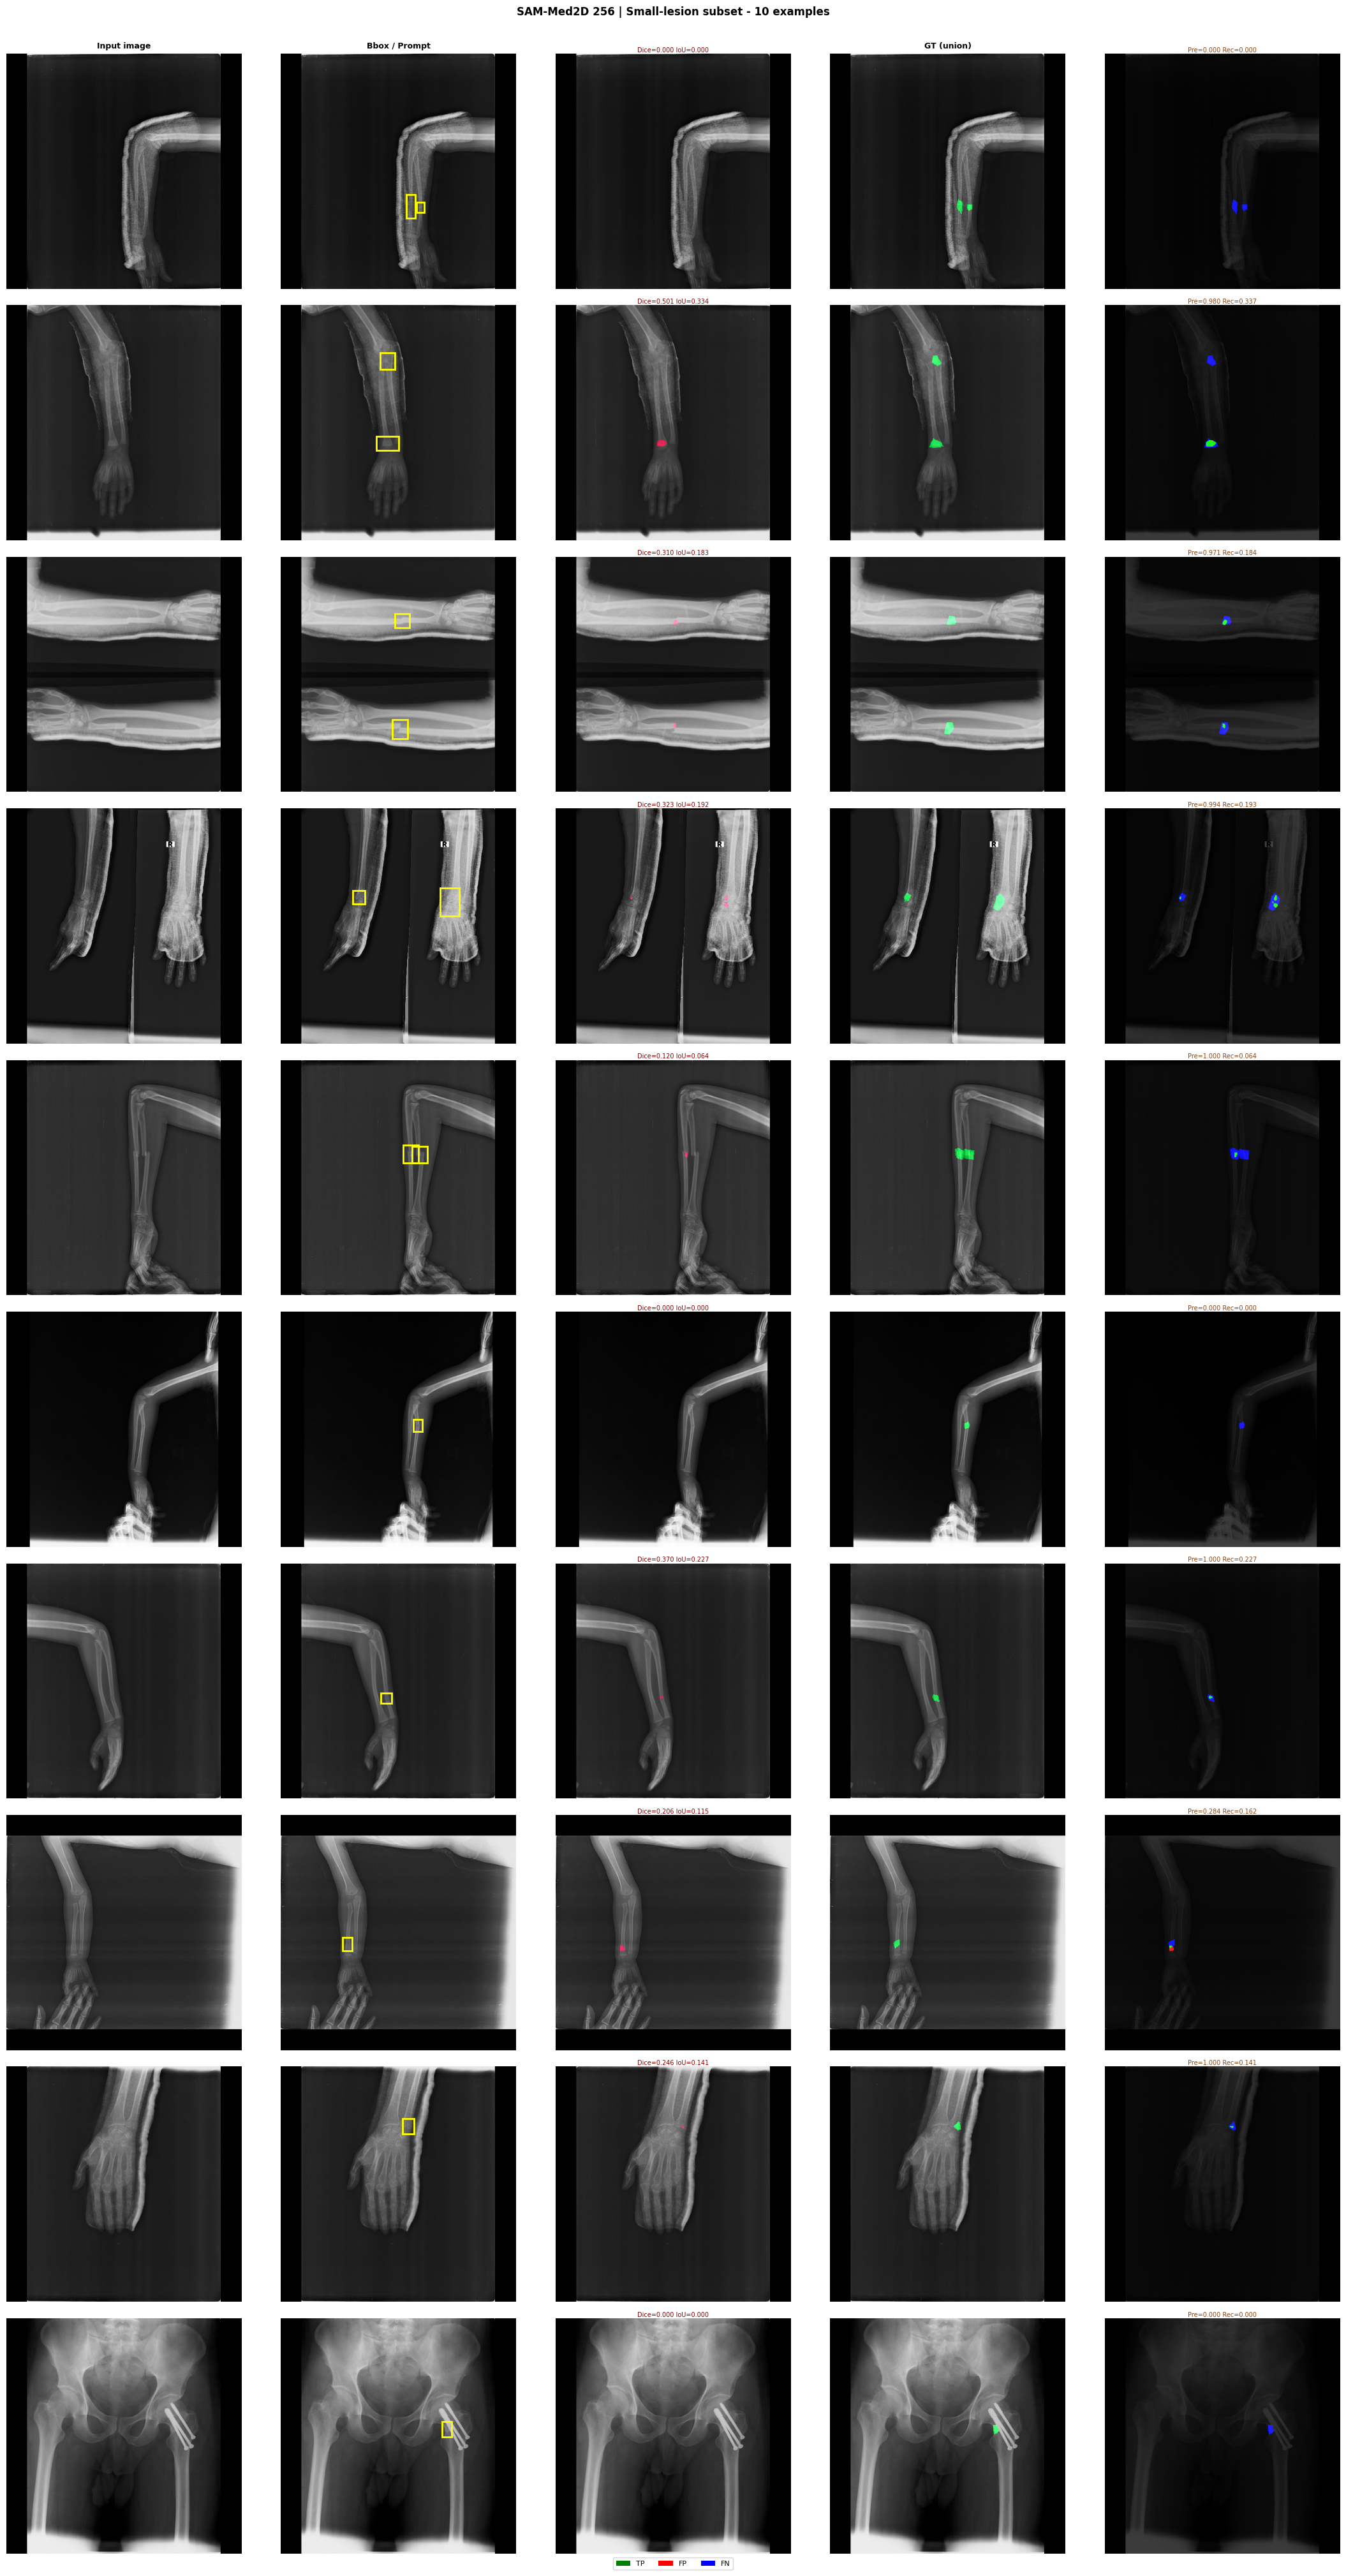

In [6]:
# ══════════════════════════════════════════════════════
# SECTION 1 - SAM-Med2D 256  (pred upsampled to 512)
# ══════════════════════════════════════════════════════
res_sam = {'small': {}}
with torch.no_grad():
    for key, lbl, stems in [('small', 'Small-lesion subset', small_lesion_stems)]:
        for st in tqdm(stems, f'SAM-{lbl}'):
            grp = stem_groups[st]
            gt_union = np.zeros((S_PGA, S_PGA), dtype=np.float32)
            prob_max = np.zeros((S_PGA, S_PGA), dtype=np.float32)
            for s in grp['samples']:
                np.maximum(gt_union, s['gt_512'], out=gt_union)
                np.maximum(prob_max, infer_sam(s['gray_256'], s['bbox_256']), out=prob_max)
            per_poly_bboxes = [s['bbox_512'] for s in grp['samples']]
            res_sam[key][st] = dict(stem=st, img_np=grp['img_np'],
                                    gt=gt_union, prob=prob_max, prompts=[],
                                    per_poly_bboxes=per_poly_bboxes,
                                    n_samples=len(grp['samples']),
                                    m=calc_metrics_img(prob_max, gt_union))

bar = '='*74; print(f'\n{bar}\n  SECTION 1 - SAM-Med2D 256 (metrics @512)\n{bar}')
SEC['sam'] = {}
for key, lbl in [('small', 'Small-lesion subset')]:
    SEC['sam'][key] = print_metrics(f'{lbl} (N=50)', [v['m'] for v in res_sam[key].values()])

for key, lbl, stems in [('small', 'Small-lesion subset', small_lesion_stems)]:
    show_s = small_lesion_balanced_test_stems
    visualize_img([res_sam[key][s] for s in show_s if s in res_sam[key]],
                  f'SAM-Med2D 256 | {lbl} - 10 examples', n=10)

PGA256-Small-lesion subset: 100%|██████████| 50/50 [00:10<00:00,  4.92it/s]



  SECTION 2 - PGA-UNet 256 (metrics @512)
  Small-lesion subset (N=50) Dice=0.7973 IoU=0.6705 Pre=0.7070 Rec=0.9356 HD95=5.62 CBL=0.9569


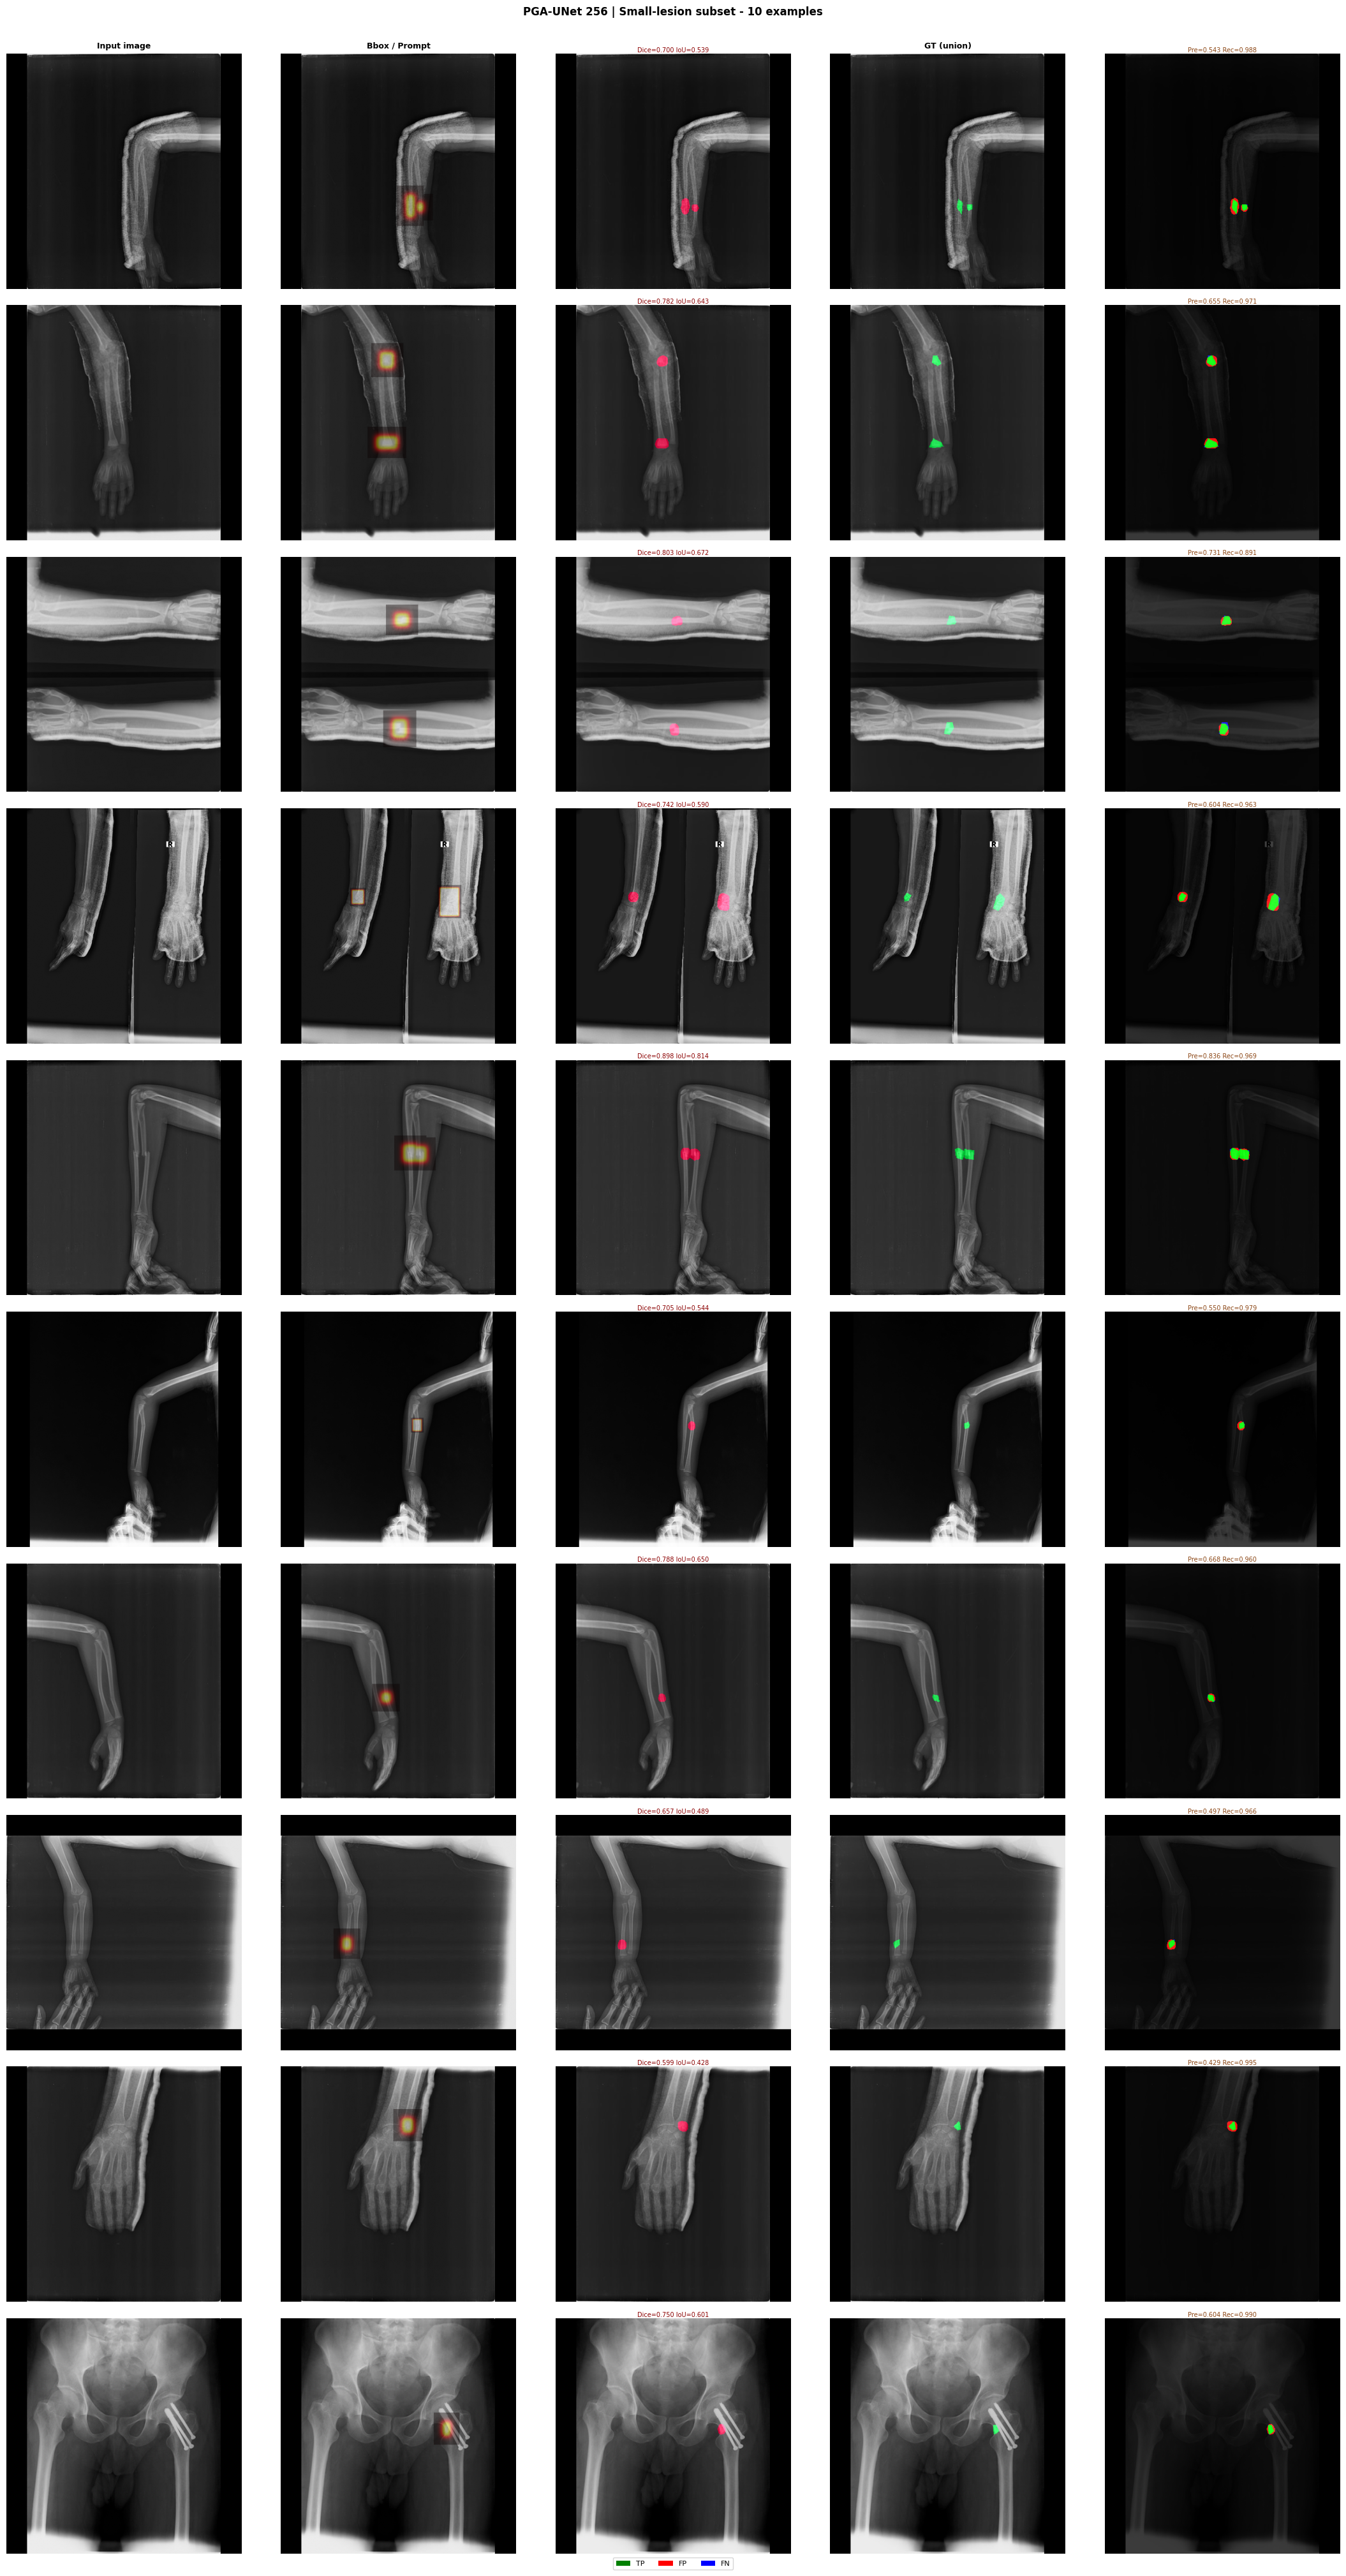

In [7]:
# ══════════════════════════════════════════════════════
# SECTION 2 - PGA-UNet 256  (pred upsampled to 512)
# ══════════════════════════════════════════════════════
res_pga256 = {'small': {}}
with torch.no_grad():
    for key, lbl, stems in [('small', 'Small-lesion subset', small_lesion_stems)]:
        for st in tqdm(stems, f'PGA256-{lbl}'):
            grp = stem_groups[st]
            gt_union = np.zeros((S_PGA, S_PGA), dtype=np.float32)
            prob_max = np.zeros((S_PGA, S_PGA), dtype=np.float32)
            prompts  = []
            for s in grp['samples']:
                np.maximum(gt_union, s['gt_512'], out=gt_union)
                np.maximum(prob_max, infer_pga256(s['img_np_256'], s['hm_256']), out=prob_max)
                # heatmap already built at 256 (letterbox, kernel=31); resize to 512 for visualization only
                prompts.append(cv2.resize(s['hm_256'], (S_PGA, S_PGA), interpolation=cv2.INTER_LINEAR))
            res_pga256[key][st] = dict(stem=st, img_np=grp['img_np'],
                                       gt=gt_union, prob=prob_max, prompts=prompts,
                                       n_samples=len(grp['samples']),
                                       m=calc_metrics_img(prob_max, gt_union))

bar = '='*74; print(f'\n{bar}\n  SECTION 2 - PGA-UNet 256 (metrics @512)\n{bar}')
SEC['pga256'] = {}
for key, lbl in [('small', 'Small-lesion subset')]:
    SEC['pga256'][key] = print_metrics(f'{lbl} (N=50)', [v['m'] for v in res_pga256[key].values()])

for key, lbl, stems in [('small', 'Small-lesion subset', small_lesion_stems)]:
    show_s = small_lesion_balanced_test_stems
    visualize_img([res_pga256[key][s] for s in show_s if s in res_pga256[key]],
                  f'PGA-UNet 256 | {lbl} - 10 examples', n=10)

PGA512-Small-lesion subset: 100%|██████████| 50/50 [00:35<00:00,  1.41it/s]



  SECTION 3 - PGA-UNet 512 (metrics @512)
  Small-lesion subset (N=50) Dice=0.8348 IoU=0.7223 Pre=0.8037 Rec=0.8895 HD95=4.83 CBL=0.9609


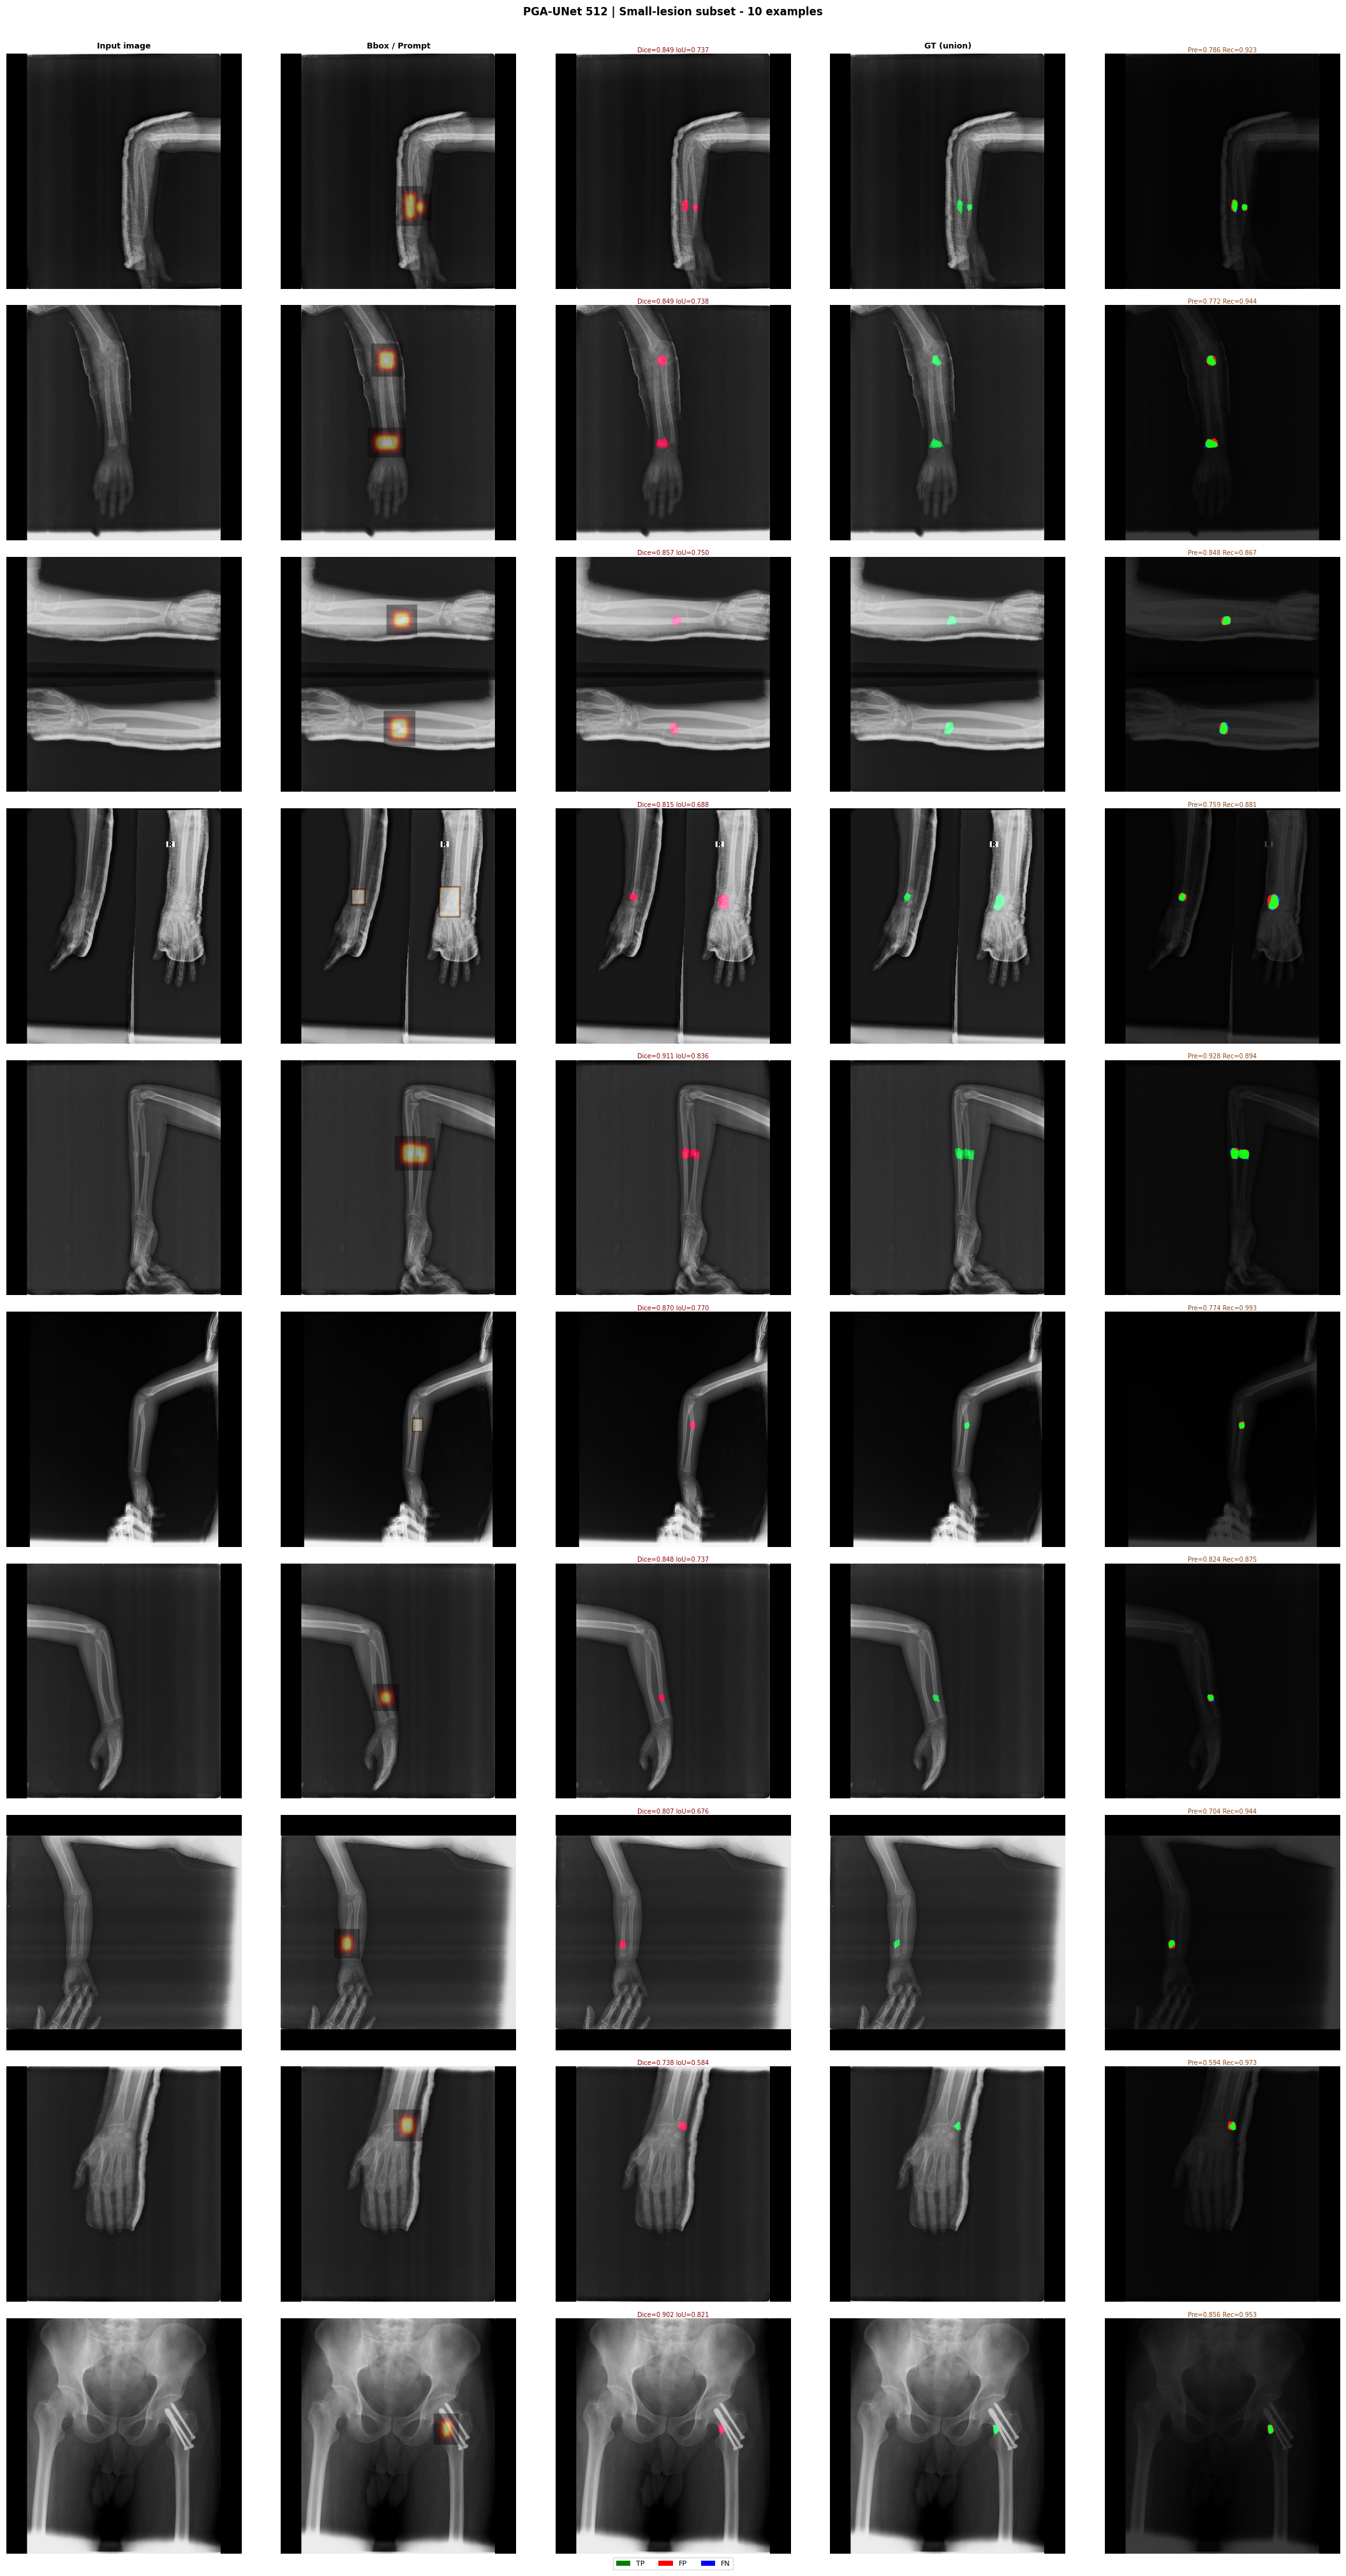

In [8]:
# ══════════════════════════════════════════════════════
# SECTION 3 - PGA-UNet 512  (native 512 metrics)
# ══════════════════════════════════════════════════════
res_pga512 = {'small': {}}
with torch.no_grad():
    for key, lbl, stems in [('small', 'Small-lesion subset', small_lesion_stems)]:
        for st in tqdm(stems, f'PGA512-{lbl}'):
            grp = stem_groups[st]
            gt_union = np.zeros((S_PGA, S_PGA), dtype=np.float32)
            prob_max = np.zeros((S_PGA, S_PGA), dtype=np.float32)
            prompts  = []
            for s in grp['samples']:
                np.maximum(gt_union, s['gt_512'], out=gt_union)
                np.maximum(prob_max, infer_pga512(s['img_np'], s['hm_512']), out=prob_max)
                prompts.append(s['hm_512'])
            res_pga512[key][st] = dict(stem=st, img_np=grp['img_np'],
                                       gt=gt_union, prob=prob_max, prompts=prompts,
                                       n_samples=len(grp['samples']),
                                       m=calc_metrics_img(prob_max, gt_union))

bar = '='*74; print(f'\n{bar}\n  SECTION 3 - PGA-UNet 512 (metrics @512)\n{bar}')
SEC['pga512'] = {}
for key, lbl in [('small', 'Small-lesion subset')]:
    SEC['pga512'][key] = print_metrics(f'{lbl} (N=50)', [v['m'] for v in res_pga512[key].values()])

for key, lbl, stems in [('small', 'Small-lesion subset', small_lesion_stems)]:
    show_s = small_lesion_balanced_test_stems
    visualize_img([res_pga512[key][s] for s in show_s if s in res_pga512[key]],
                  f'PGA-UNet 512 | {lbl} - 10 examples', n=10)


══════════════════════════════════════════════════════════════════════════════════════════
  COMPARISON TABLE  |  Small-lesion subset
══════════════════════════════════════════════════════════════════════════════════════════
  Subset                   Model                   Dice     IoU     Pre     Rec     HD95     CBL
  ────────────────────────────────────────────────────────────────────────────────────────────────
  Small-lesion subset      SAM-Med2D 256         0.3736  0.2628  0.6860  0.2939   105.19  0.7116
  Small-lesion subset      PGA-UNet 256          0.7973  0.6705  0.7070  0.9356     5.62  0.9569
  Small-lesion subset      PGA-UNet 512          0.8348  0.7223  0.8037  0.8895     4.83  0.9609
                           Delta PGA512-SAM256  +0.4612
                           Delta PGA256-SAM256  +0.4238
  ────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════

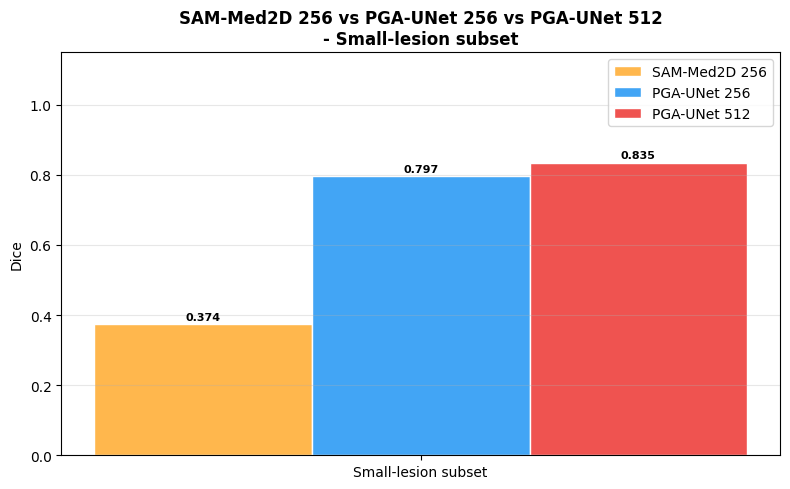

Saved plot: results/subcat_3model_small_lesion_bar.png


In [9]:
# ══════════════════════════════════════════════════════
# SUMMARY CELL - Compare SAM-256 vs PGA-256 vs PGA-512 on the small-lesion subset
# ══════════════════════════════════════════════════════
import csv, os

bar = '═'*90
print(f'\n{bar}')
print('  COMPARISON TABLE  |  Small-lesion subset')
print(f'{bar}')
print(f"  {'Subset':<24} {'Model':<20} {'Dice':>7} {'IoU':>7} {'Pre':>7} {'Rec':>7} {'HD95':>8} {'CBL':>7}")
print(f"  {'─'*96}")

csv_rows = []
model_cfg = [('SAM-Med2D 256','sam'), ('PGA-UNet 256','pga256'), ('PGA-UNet 512','pga512')]
for key, lbl in [('small', 'Small-lesion subset')]:
    for model, mkey in model_cfg:
        m = SEC[mkey][key]
        print(f"  {lbl:<24} {model:<20}"
              f" {m['dice']:>7.4f} {m['iou']:>7.4f} {m['precision']:>7.4f}"
              f" {m['recall']:>7.4f} {m['hd95']:>8.2f} {m['cbl']:>7.4f}")
        csv_rows.append([lbl, model, 50] + [f"{m[k]:.4f}" for k in KEYS])
    d512=SEC['pga512'][key]['dice']; d256=SEC['pga256'][key]['dice']; ds=SEC['sam'][key]['dice']
    print(f"  {'':24} {'Delta PGA512-SAM256':<20} {d512-ds:>+7.4f}")
    print(f"  {'':24} {'Delta PGA256-SAM256':<20} {d256-ds:>+7.4f}")
    print(f"  {'─'*96}")
print(bar)

os.makedirs('results', exist_ok=True)
with open('results/subcat_3model_small_lesion.csv','w',newline='',encoding='utf-8') as f:
    csv.writer(f).writerows([['group','model','N']+KEYS]+csv_rows)
print('Saved CSV: results/subcat_3model_small_lesion.csv')

# ── Bar chart ─────────────────────────────────────────────────────────
x_labels = ['Small-lesion subset']
x = np.arange(1); w = 0.22
fig, ax = plt.subplots(figsize=(8, 5))
colors  = {'sam':'#ffb74d', 'pga256':'#42a5f5', 'pga512':'#ef5350'}
labels  = {'sam':'SAM-Med2D 256', 'pga256':'PGA-UNet 256', 'pga512':'PGA-UNet 512'}
for i, mkey in enumerate(['sam','pga256','pga512']):
    vals = [SEC[mkey]['small']['dice']]
    bars = ax.bar(x + (i-1)*w, vals, w, label=labels[mkey], color=colors[mkey], edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.012, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel('Dice'); ax.set_ylim(0, 1.15)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.set_title('SAM-Med2D 256 vs PGA-UNet 256 vs PGA-UNet 512\n- Small-lesion subset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/subcat_3model_small_lesion_bar.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved plot: results/subcat_3model_small_lesion_bar.png')